
--- Imbalance Handling (Logistic Regression) ---
Target Balance (Train):
 survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64
                 Precision    Recall        F1
Baseline          0.790323  0.720588  0.753846
Balanced_Weight   0.753425  0.808824  0.780142
SMOTE             0.785714  0.808824  0.797101

Best RF Params: {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}
OOB Score of Best Model: 0.8214

--- Model Comparison Tables ---
Classification Metrics:
                      Accuracy  Precision    Recall  F1 Score       AUC
Logistic Regression  0.820225   0.790323  0.720588  0.753846  0.865775
Decision Tree        0.820225   0.790323  0.720588  0.753846  0.834091
Random Forest        0.808989   0.750000  0.750000  0.750000  0.829479

Regression Metrics:
                          MAE      RMSE        R2    Adj_R2
Linear Regression  20.686678  42.57064  0.320728  0.305022

Pipeline saved successfully.
Reloaded P

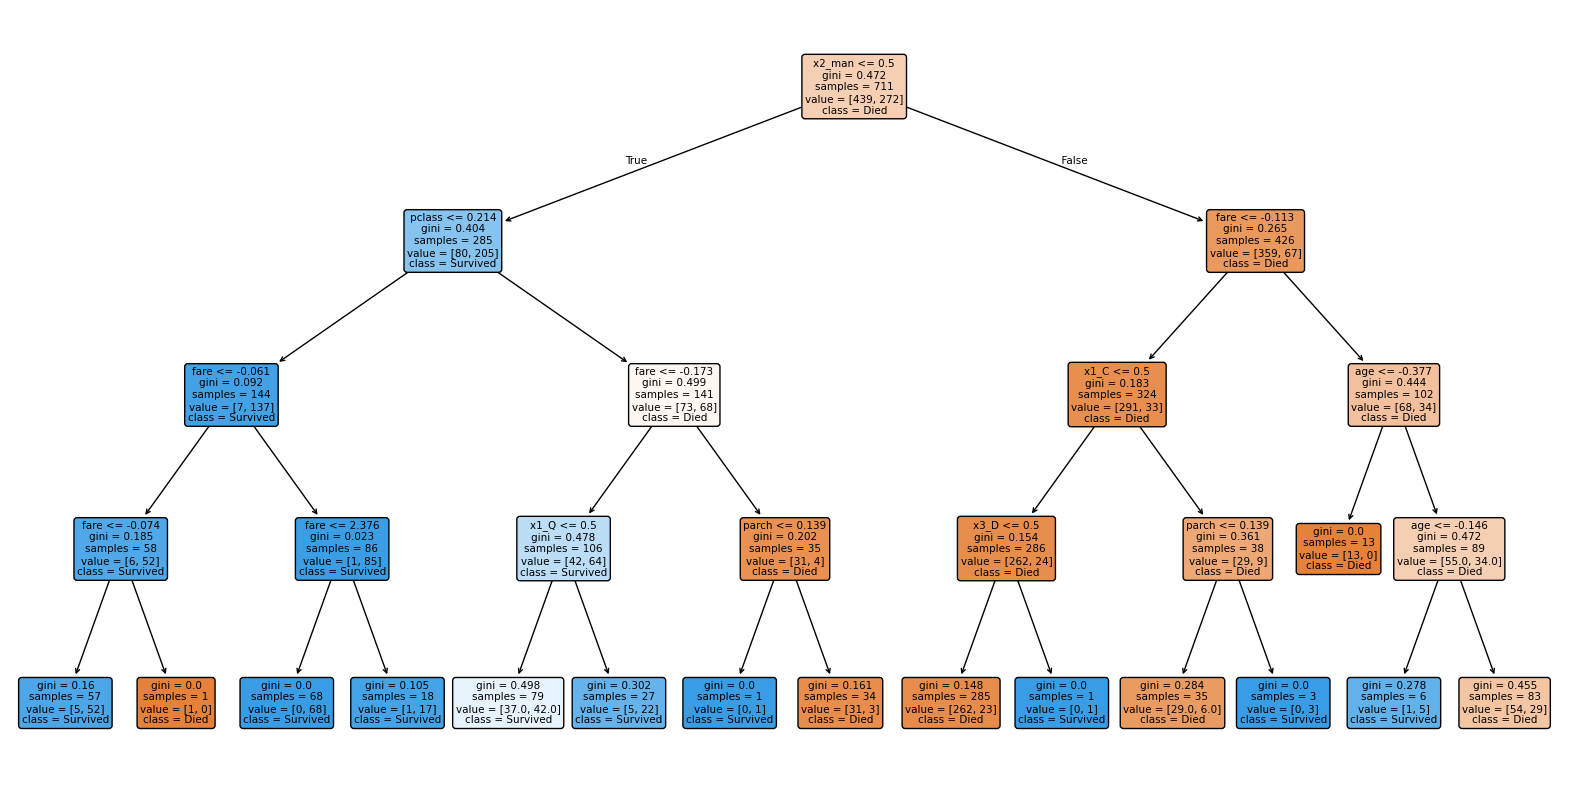

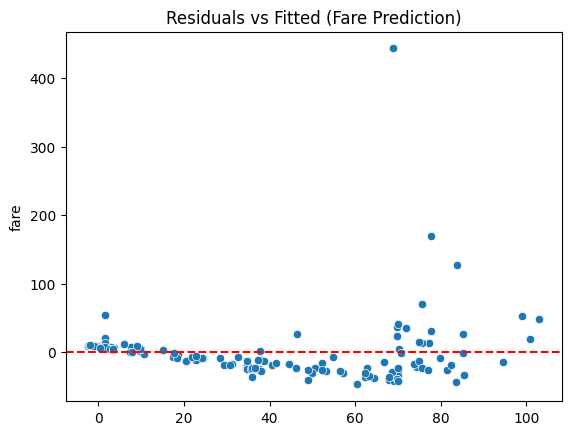

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             mean_absolute_error, mean_squared_error, r2_score)
from imblearn.over_sampling import SMOTE
import joblib

# Load the cleaned dataset from Part A
df = pd.read_csv("titanic_cleaned.csv")

X = df.drop(columns=['survived', 'family_size']) # family_size was just for EDA
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 8. PREPROCESSING PIPELINE
num_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
cat_features = ['sex', 'embarked', 'who', 'deck'] # Excluded redundant boolean flags

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

# 9 & 10. TRAIN AND EVALUATE CLASSIFIERS
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=4),
    'Random Forest': RandomForestClassifier(random_state=42)
}

metrics_dict = {}

for name, clf in classifiers.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    metrics_dict[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    }

    # Plot Decision Tree
    if name == 'Decision Tree':
        plt.figure(figsize=(20,10))
        feature_names = num_features + list(pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out())
        plot_tree(pipe.named_steps['classifier'], feature_names=feature_names, class_names=['Died', 'Survived'], filled=True, rounded=True)
        plt.savefig("04_decision_tree.png")

# 11. IMBALANCE HANDLING COMPARISON
print("\n--- Imbalance Handling (Logistic Regression) ---")
print("Target Balance (Train):\n", y_train.value_counts(normalize=True))

# Extract preprocessed arrays to apply SMOTE cleanly
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# a) Baseline (Already trained above)
y_pred_base = classifiers['Logistic Regression'].predict(X_test_processed)

# b) Class Weights
lr_weighted = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_weighted.fit(X_train_processed, y_train)
y_pred_weight = lr_weighted.predict(X_test_processed)

# c) SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_processed, y_train)
lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_train_sm, y_train_sm)
y_pred_smote = lr_smote.predict(X_test_processed)

imb_results = {
    'Baseline': [precision_score(y_test, y_pred_base), recall_score(y_test, y_pred_base), f1_score(y_test, y_pred_base)],
    'Balanced_Weight': [precision_score(y_test, y_pred_weight), recall_score(y_test, y_pred_weight), f1_score(y_test, y_pred_weight)],
    'SMOTE': [precision_score(y_test, y_pred_smote), recall_score(y_test, y_pred_smote), f1_score(y_test, y_pred_smote)]
}
df_imb = pd.DataFrame(imb_results, index=['Precision', 'Recall', 'F1']).T
print(df_imb)

# 12. HYPERPARAMETER TUNING
rf = RandomForestClassifier(oob_score=True, random_state=42)
rf_pipe = Pipeline([('preprocessor', preprocessor), ('classifier', rf)])

param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
oob_score = best_model.named_steps['classifier'].oob_score_
print(f"\nBest RF Params: {grid_search.best_params_}")
print(f"OOB Score of Best Model: {oob_score:.4f}")

# 13. REGRESSION SIDE-TASK (Predict Fare)
# Use numeric features + sex for regression (drop survived/fare)
X_reg = df[['pclass', 'age', 'sibsp', 'parch']]
y_reg = df['fare']

X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])
reg_pipe.fit(X_r_train, y_r_train)
y_r_pred = reg_pipe.predict(X_r_test)

mae = mean_absolute_error(y_r_test, y_r_pred)
rmse = np.sqrt(mean_squared_error(y_r_test, y_r_pred))
r2 = r2_score(y_r_test, y_r_pred)
n, p = X_r_test.shape
adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

reg_metrics = pd.DataFrame({'MAE': [mae], 'RMSE': [rmse], 'R2': [r2], 'Adj_R2': [adj_r2]}, index=['Linear Regression'])

# Residual Plot
plt.figure()
residuals = y_r_test - y_r_pred
sns.scatterplot(x=y_r_pred, y=residuals)
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuals vs Fitted (Fare Prediction)")
plt.savefig("05_residuals.png")

# 14. FINAL COMPARISON TABLES
print("\n--- Model Comparison Tables ---")
df_class_metrics = pd.DataFrame(metrics_dict).T
print("Classification Metrics:\n", df_class_metrics)
print("\nRegression Metrics:\n", reg_metrics)

# 15. SAVE COMPLETE PIPELINE & RELOAD
joblib.dump(best_model, 'titanic_best_pipeline.pkl')
print("\nPipeline saved successfully.")

# Reload and test on raw input (First 2 rows of original unseen data)
loaded_pipe = joblib.load('titanic_best_pipeline.pkl')
sample_raw_data = X_test.head(2)
predictions = loaded_pipe.predict(sample_raw_data)
print(f"Reloaded Pipeline Predictions on raw sample: {predictions}")